# Mixture of Gaussian Processes for Strength Progression

A fully generative Bayesian model — no neural networks. Each lifter's strength trajectory is a convex combination of $K$ shared archetype curves, each modeled as a Gaussian process.

## Generative story

**Global (shared across all lifters):**
1. Draw Dirichlet concentration $\alpha \sim \text{Gamma}(2, 2)$
2. Draw observation noise $\sigma_y \sim \text{LogNormal}(1, 0.5)$
3. For each archetype $k = 1, \ldots, K$:
   - Draw kernel lengthscale $\ell_k \sim \text{LogNormal}(\mu_\ell, \sigma_\ell)$
   - Draw kernel amplitude $\sigma_{f,k} \sim \text{LogNormal}(\mu_f, \sigma_f)$
   - Draw inducing values $u_k \sim \mathcal{N}(0, K_{ZZ}^{(k)})$ at inducing locations $Z_{1:M-1}$, with the value at $Z_0 = 0$ anchored to 0 so $f_k(0) = 0$

**Per lifter $i$:**
1. Draw mixing weights $\pi_i \sim \text{Dirichlet}(\alpha \cdot \mathbf{1}_K)$
2. For each meet $j$ at time $t_{i,j}$:
   - Compute archetype values: $f_k(t_{i,j}) = K_{tZ} K_{ZZ}^{-1} u_k$
   - Observe $y_{i,j} \sim \mathcal{N}\left(\sum_k \pi_{i,k} f_k(t_{i,j}),\ \sigma_y^2\right)$

## 1. Imports and setup

In [1]:
import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoNormal, init_to_value
from pyro.optim import ClippedAdam
from itertools import permutations
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
pyro.set_rng_seed(0)
np.random.seed(0)

## 2. Kernel and model definition

These are independent of whether we run on synthetic or real data.

In [2]:
def rbf_kernel(t1, t2, lengthscale, amplitude, jitter=1e-5):
    """RBF kernel with jitter on the diagonal."""
    sq = (t1.unsqueeze(-1) - t2.unsqueeze(-2)).pow(2)
    K = amplitude.pow(2) * torch.exp(-0.5 * sq / lengthscale.pow(2))
    if t1.shape == t2.shape and torch.equal(t1, t2):
        K = K + jitter * torch.eye(t1.shape[-1], dtype=K.dtype)
    return K


def model(t_obs, y_obs, lifter_id, N, K, Z):
    """Mixture-of-GPs model. Z[0] must be 0.0 (anchor f_k(0) = 0)."""
    M = Z.shape[0]
    M_free = M - 1

    # Global hyperparameters
    alpha   = pyro.sample("alpha",   dist.Gamma(2.0, 2.0))
    sigma_y = pyro.sample("sigma_y", dist.LogNormal(1.0, 0.5))

    # Per-archetype GP hyperparameters
    with pyro.plate("archetypes", K):
        lengthscale = pyro.sample("lengthscale", dist.LogNormal(2.5, 0.4))
        amplitude   = pyro.sample("amplitude",   dist.LogNormal(3.5, 0.4))

    # Inducing values: anchor first to 0, sample the rest from GP prior
    u_full_list = []
    for k in range(K):
        ls_k  = lengthscale[..., k]
        amp_k = amplitude[..., k]
        Z_free  = Z[1:]
        K_free  = rbf_kernel(Z_free, Z_free, ls_k, amp_k)
        L_free  = torch.linalg.cholesky(K_free)
        u_free  = pyro.sample(f"u_{k}", dist.MultivariateNormal(
            torch.zeros(M_free), scale_tril=L_free))
        while u_free.dim() > 1:
            u_free = u_free.squeeze(0)
        u_full = torch.cat([torch.zeros(1, dtype=u_free.dtype), u_free])
        u_full_list.append(u_full)
    u = torch.stack(u_full_list, dim=0)

    # Per-lifter mixing weights
    with pyro.plate("lifters", N):
        pi = pyro.sample("pi", dist.Dirichlet(alpha * torch.ones(K)))

    # GP predictive mean at observation times
    f_at_obs = torch.zeros(K, t_obs.shape[0])
    for k in range(K):
        ls_k  = lengthscale[..., k]
        amp_k = amplitude[..., k]
        K_ZZ  = rbf_kernel(Z, Z, ls_k, amp_k)
        K_tZ  = rbf_kernel(t_obs, Z, ls_k, amp_k)
        f_at_obs[k] = K_tZ @ torch.linalg.solve(K_ZZ, u[k])

    # Mixed mean and likelihood
    pi_per_obs = pi[lifter_id]
    mu = (pi_per_obs * f_at_obs.T).sum(dim=-1)

    with pyro.plate("obs", t_obs.shape[0]):
        pyro.sample("y", dist.Normal(mu, sigma_y), obs=y_obs)

---
# Part A: Synthetic data validation

Generate data from known truth, fit the model, and verify we can recover the archetypes and mixing weights.

Synthetic: N=80 lifters, 763 observations


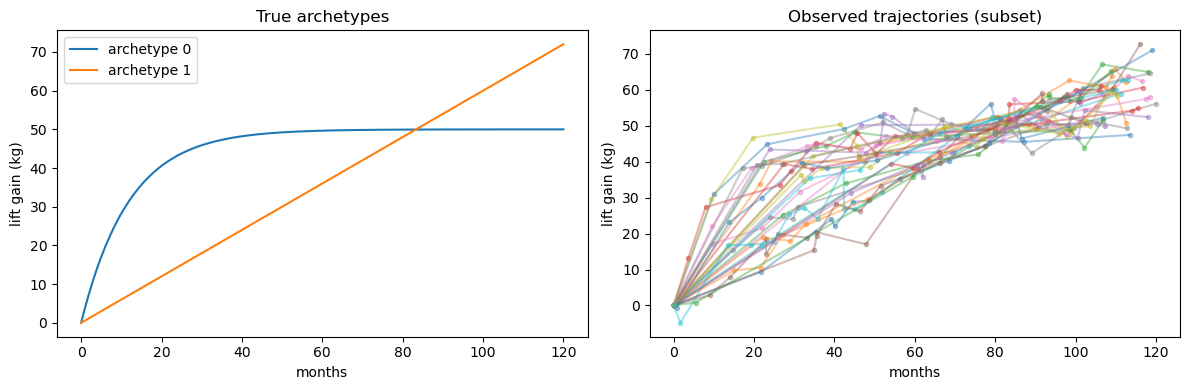

In [3]:
def true_archetype(k, t):
    """Two hand-crafted archetypes on t in [0, 120] months."""
    if k == 0:
        return 50.0 * (1.0 - np.exp(-t / 12.0))     # fast plateau
    elif k == 1:
        return 0.6 * t                                # steady linear

def simulate_dataset(N=80, K_true=2, T_max=120.0, alpha_true=0.5,
                     noise_std=3.0, min_meets=4, max_meets=15, seed=0):
    rng = np.random.default_rng(seed)
    pi_true = rng.dirichlet(alpha_true * np.ones(K_true), size=N)
    times, lifts, lifter_ids = [], [], []
    for i in range(N):
        n_meets = rng.integers(min_meets, max_meets + 1)
        t_i = np.sort(rng.uniform(0.0, T_max, size=n_meets))
        t_i[0] = 0.0
        mean = sum(pi_true[i, k] * true_archetype(k, t_i) for k in range(K_true))
        y_i = mean + rng.normal(0.0, noise_std, size=n_meets)
        y_i[0] = 0.0
        times.append(t_i); lifts.append(y_i); lifter_ids.append(np.full(n_meets, i))
    return (np.concatenate(times), np.concatenate(lifts),
            np.concatenate(lifter_ids), pi_true)

t_obs_syn, y_obs_syn, lid_syn, pi_true = simulate_dataset()
N_syn = int(lid_syn.max() + 1)
print(f"Synthetic: N={N_syn} lifters, {len(t_obs_syn)} observations")

# Plot truth
t_grid_syn = np.linspace(0, 120, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k in range(2):
    axes[0].plot(t_grid_syn, true_archetype(k, t_grid_syn), label=f'archetype {k}')
axes[0].set_xlabel('months'); axes[0].set_ylabel('lift gain (kg)')
axes[0].set_title('True archetypes'); axes[0].legend()
for i in range(min(N_syn, 30)):
    mask = lid_syn == i
    axes[1].plot(t_obs_syn[mask], y_obs_syn[mask], '.-', alpha=0.4)
axes[1].set_xlabel('months'); axes[1].set_ylabel('lift gain (kg)')
axes[1].set_title('Observed trajectories (subset)')
plt.tight_layout(); plt.show()

### Fit on synthetic data

step     0  -ELBO = 363055.2
step   500  -ELBO = 2342.0
step  1000  -ELBO = 2120.8
step  1500  -ELBO = 2116.0
step  2000  -ELBO = 2110.3
step  2500  -ELBO = 2185.0
step  3000  -ELBO = 2104.4
step  3500  -ELBO = 2107.1
step  4000  -ELBO = 2122.4
step  4500  -ELBO = 2105.3


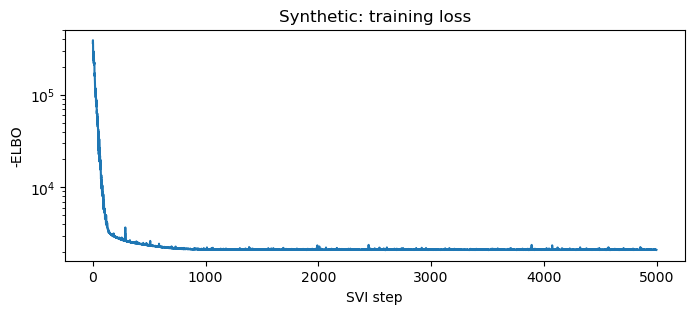

In [4]:
K_syn   = 2
M       = 13
T_max_syn = 120.0
Z_syn   = torch.linspace(0.0, T_max_syn, M)
Z_free_syn = Z_syn[1:].numpy()

init_dict_syn = {
    "u_0": torch.tensor(50.0 * (1.0 - np.exp(-Z_free_syn / 15.0))),
    "u_1": torch.tensor(0.5 * Z_free_syn),
}

t_t  = torch.tensor(t_obs_syn)
y_t  = torch.tensor(y_obs_syn)
id_t = torch.tensor(lid_syn, dtype=torch.long)

pyro.clear_param_store()
guide_syn = AutoNormal(model, init_loc_fn=init_to_value(values=init_dict_syn))
optimizer = ClippedAdam({"lr": 0.02, "clip_norm": 10.0})
svi = SVI(model, guide_syn, optimizer, loss=Trace_ELBO())

losses_syn = []
for step in range(5000):
    loss = svi.step(t_t, y_t, id_t, N_syn, K_syn, Z_syn)
    losses_syn.append(loss)
    if step % 500 == 0:
        print(f"step {step:5d}  -ELBO = {loss:.1f}")

plt.figure(figsize=(8, 3))
plt.plot(losses_syn); plt.yscale('log')
plt.xlabel('SVI step'); plt.ylabel('-ELBO'); plt.title('Synthetic: training loss')
plt.show()

### Verify archetype recovery

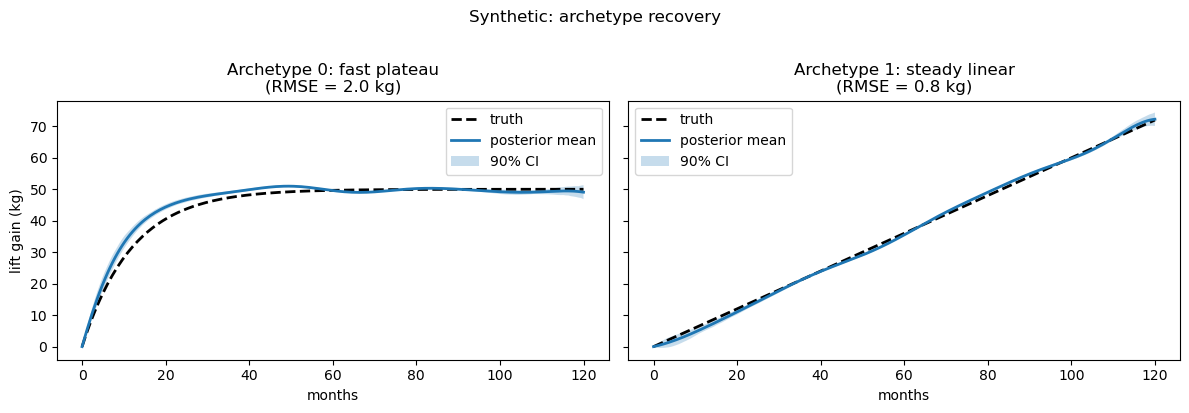

pi MAE: 0.058  (random ~0.25, perfect 0.0)


In [5]:
def extract_posterior(guide, t_t, id_t, N, K, Z, t_grid, n_samples=300):
    """Draw posterior samples and evaluate archetypes on a time grid.
    Returns samples dict, f_grid array (n_samples, K, |grid|)."""
    return_sites = [f"u_{k}" for k in range(K)] + ["lengthscale", "amplitude", "pi"]
    predictive = Predictive(model, guide=guide, num_samples=n_samples,
                            return_sites=return_sites)
    samples = predictive(t_t, None, id_t, N, K, Z)

    # Squeeze extra dims
    for k in range(K):
        while samples[f"u_{k}"].dim() > 2:
            samples[f"u_{k}"] = samples[f"u_{k}"].squeeze(1)
    for key in ["lengthscale", "amplitude"]:
        while samples[key].dim() > 2:
            samples[key] = samples[key].squeeze(1)

    # Reconstruct full inducing vectors (prepend anchor 0)
    def full_u(k):
        u_free = samples[f"u_{k}"]
        return torch.cat([torch.zeros(u_free.shape[0], 1, dtype=u_free.dtype),
                          u_free], dim=-1)

    t_grid_t = torch.tensor(t_grid)
    n_s = samples["lengthscale"].shape[0]
    f_grid = np.zeros((n_s, K, len(t_grid)))
    for s in range(n_s):
        for k in range(K):
            ls  = samples["lengthscale"][s, k]
            amp = samples["amplitude"][s, k]
            u_k = full_u(k)[s]
            K_ZZ = rbf_kernel(Z, Z, ls, amp)
            K_tZ = rbf_kernel(t_grid_t, Z, ls, amp)
            f_grid[s, k] = (K_tZ @ torch.linalg.solve(K_ZZ, u_k)).detach().numpy()

    return samples, f_grid, full_u


samples_syn, f_grid_syn, full_u_syn = extract_posterior(
    guide_syn, t_t, id_t, N_syn, K_syn, Z_syn, t_grid_syn)

f_mean_syn = f_grid_syn.mean(axis=0)
f_lo_syn   = np.quantile(f_grid_syn, 0.05, axis=0)
f_hi_syn   = np.quantile(f_grid_syn, 0.95, axis=0)

true_curves = np.stack([true_archetype(k, t_grid_syn) for k in range(K_syn)])
best_perm = min(permutations(range(K_syn)),
                key=lambda p: ((f_mean_syn[list(p)] - true_curves) ** 2).sum())

fig, axes = plt.subplots(1, K_syn, figsize=(12, 4), sharey=True)
labels = ['fast plateau', 'steady linear']
for k_true in range(K_syn):
    k_post = best_perm[k_true]
    axes[k_true].plot(t_grid_syn, true_curves[k_true], 'k--', lw=2, label='truth')
    axes[k_true].plot(t_grid_syn, f_mean_syn[k_post], 'C0', lw=2, label='posterior mean')
    axes[k_true].fill_between(t_grid_syn, f_lo_syn[k_post], f_hi_syn[k_post],
                              alpha=0.25, label='90% CI')
    rmse = np.sqrt(((f_mean_syn[k_post] - true_curves[k_true]) ** 2).mean())
    axes[k_true].set_title(f'Archetype {k_true}: {labels[k_true]}\n(RMSE = {rmse:.1f} kg)')
    axes[k_true].set_xlabel('months'); axes[k_true].legend()
axes[0].set_ylabel('lift gain (kg)')
plt.suptitle('Synthetic: archetype recovery', y=1.02)
plt.tight_layout(); plt.show()

# pi recovery
pi_post_syn = samples_syn["pi"].mean(dim=0).numpy()
pi_post_aligned = pi_post_syn[:, list(best_perm)]
mae = np.abs(pi_post_aligned - pi_true).mean()
print(f"pi MAE: {mae:.3f}  (random ~0.25, perfect 0.0)")

---
# Part B: Real data — OpenPowerlifting

## 3. Load and preprocess

In [6]:
df = pd.read_csv("openpowerlifting.csv")

# ── 1. Filter to raw male squats ──────────────────────────────────────────────
df = df[
    (df["Equipment"] == "Raw") &
    (df["Sex"]       == "M")   &
    (df["Best3SquatKg"] > 0)   &
    (df["Event"].str.contains("S"))
].copy()

# ── 2. Parse dates and sort ───────────────────────────────────────────────────
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Name", "Date"]).reset_index(drop=True)

# ── 3. Months since debut ─────────────────────────────────────────────────────
debut_date = df.groupby("Name")["Date"].transform("min")
df["months"] = ((df["Date"] - debut_date) / pd.Timedelta(days=30.44)).round(2)

# ── 4. Normalize squat (subtract debut) ───────────────────────────────────────
debut_squat = df.groupby("Name")["Best3SquatKg"].transform("first")
df["squat_gain"] = df["Best3SquatKg"] - debut_squat

# ── 5. Drop lifters with fewer than 4 meets ──────────────────────────────────
meet_counts = df.groupby("Name")["Date"].transform("count")
df = df[meet_counts >= 4].copy()

# ── 6. Deduplicate same-day entries (keep best squat) ─────────────────────────
df = (df.sort_values("Best3SquatKg", ascending=False)
        .drop_duplicates(subset=["Name", "Date"])
        .sort_values(["Name", "Date"])
        .reset_index(drop=True))

# ── 7. Keep only improving lifters (final >= debut) ───────────────────────────
final_squat = df.groupby("Name")["Best3SquatKg"].last()
debut_squat_grp = df.groupby("Name")["Best3SquatKg"].first()
improving = final_squat[final_squat >= debut_squat_grp].index
df = df[df["Name"].isin(improving)].copy().reset_index(drop=True)

# ── 8. Cap careers at 120 months (10 years) ──────────────────────────────────
df = df[df["months"] <= 120].copy()

# Re-apply minimum meets after capping
meet_counts = df.groupby("Name")["Date"].transform("count")
df = df[meet_counts >= 4].copy().reset_index(drop=True)

# ── 9. Remap lifter IDs (must be contiguous 0..N-1) ──────────────────────────
lifter_names = df["Name"].unique()
name_to_id   = {name: i for i, name in enumerate(lifter_names)}
df["lifter_id"] = df["Name"].map(name_to_id)

# ── 10. Extract arrays ────────────────────────────────────────────────────────
t_real         = df["months"].values.astype(np.float64)
y_real         = df["squat_gain"].values.astype(np.float64)
lifter_id_real = df["lifter_id"].values.astype(np.int64)
N_real         = int(lifter_id_real.max() + 1)

print(f"Lifters:      {N_real}")
print(f"Observations: {len(t_real)}")
print(f"Time range:   0 – {t_real.max():.1f} months")
print(f"Gain range:   {y_real.min():.1f} – {y_real.max():.1f} kg")
print(f"Meets/lifter: {len(t_real)/N_real:.1f} on average")

/var/folders/55/lpwf841j0llg5sltzw6jc3lh0000gn/T/ipykernel_9153/4193359819.py:1: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("openpowerlifting.csv")


Lifters:      10492
Observations: 63354
Time range:   0 – 119.3 months
Gain range:   -220.0 – 252.1 kg
Meets/lifter: 6.0 on average


### Explore: plot 5 most active lifters

Plotting: ['Erik Røen', 'Ivan Otim', 'Andrzej Stanaszek', 'Scott Hill', 'Teemu Hällfors']


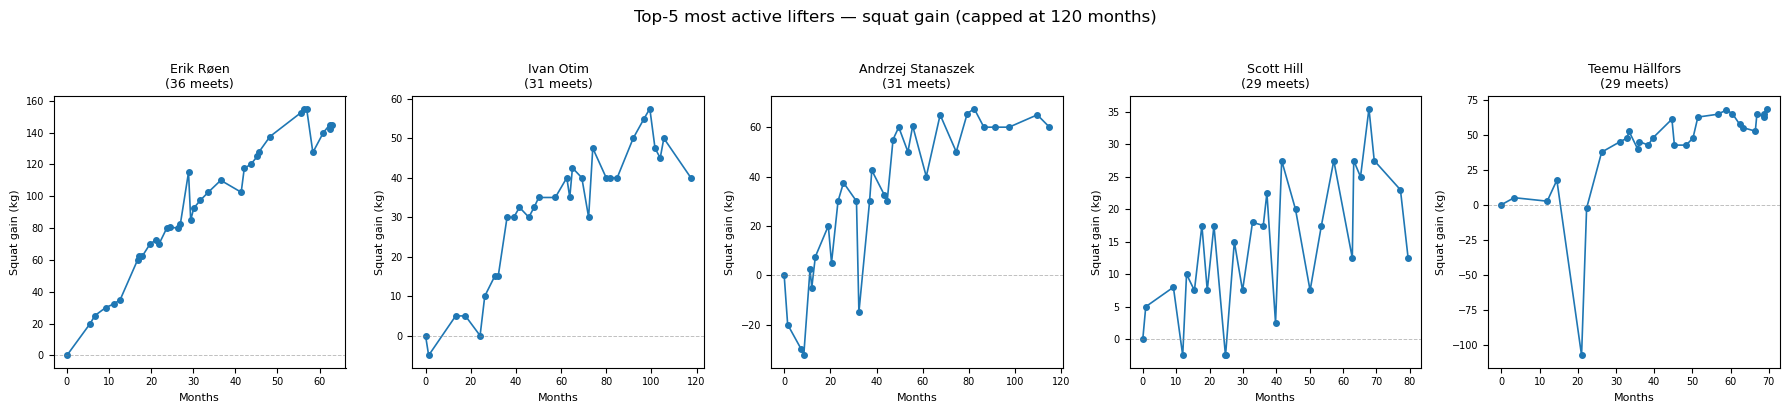

In [7]:
meet_cts = df.groupby("Name")["Date"].count().sort_values(ascending=False)
top5 = meet_cts.index[:5].tolist()
print("Plotting:", top5)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, name in zip(axes, top5):
    sub = df[df["Name"] == name].sort_values("months")
    ax.plot(sub["months"], sub["squat_gain"], "o-", ms=4, lw=1.2)
    ax.axhline(0, color="gray", lw=0.7, ls="--", alpha=0.5)
    ax.set_title(f"{name}\n({len(sub)} meets)", fontsize=9)
    ax.set_xlabel("Months", fontsize=8)
    ax.set_ylabel("Squat gain (kg)", fontsize=8)
    ax.tick_params(labelsize=7)
plt.suptitle("Top-5 most active lifters — squat gain (capped at 120 months)", y=1.02)
plt.tight_layout(); plt.show()

## 4. Fit model on real data (K=2)

step     0  -ELBO = 138537016.9
step   500  -ELBO = 287620.7
step  1000  -ELBO = 281567.9
step  1500  -ELBO = 279020.1


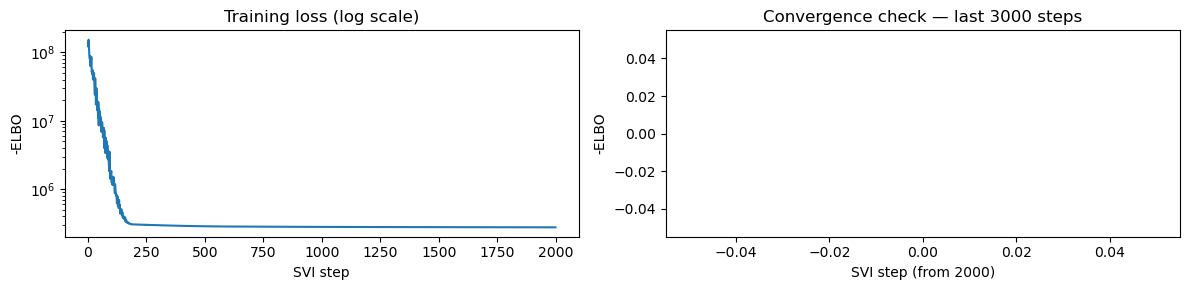

In [8]:
K       = 2
M       = 13
T_max   = 120.0
Z       = torch.linspace(0.0, T_max, M)
Z_free_np = Z[1:].numpy()

init_dict = {
    "u_0": torch.tensor(50.0 * (1.0 - np.exp(-Z_free_np / 15.0))),   # plateau
    "u_1": torch.tensor(0.8 * Z_free_np),                             # linear
}

t_t  = torch.tensor(t_real,         dtype=torch.float64)
y_t  = torch.tensor(y_real,         dtype=torch.float64)
id_t = torch.tensor(lifter_id_real, dtype=torch.long)
N    = N_real

pyro.clear_param_store()
guide = AutoNormal(model, init_loc_fn=init_to_value(values=init_dict))
optimizer = ClippedAdam({"lr": 0.02, "clip_norm": 10.0})
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

n_steps = 2000
losses = []
for step in range(n_steps):
    loss = svi.step(t_t, y_t, id_t, N, K, Z)
    losses.append(loss)
    if step % 500 == 0:
        print(f"step {step:5d}  -ELBO = {loss:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(losses); axes[0].set_yscale('log')
axes[0].set_xlabel('SVI step'); axes[0].set_ylabel('-ELBO')
axes[0].set_title('Training loss (log scale)')
axes[1].plot(losses[2000:])
axes[1].set_xlabel('SVI step (from 2000)'); axes[1].set_ylabel('-ELBO')
axes[1].set_title('Convergence check — last 3000 steps')
plt.tight_layout(); plt.show()

## 5. Recovered archetypes

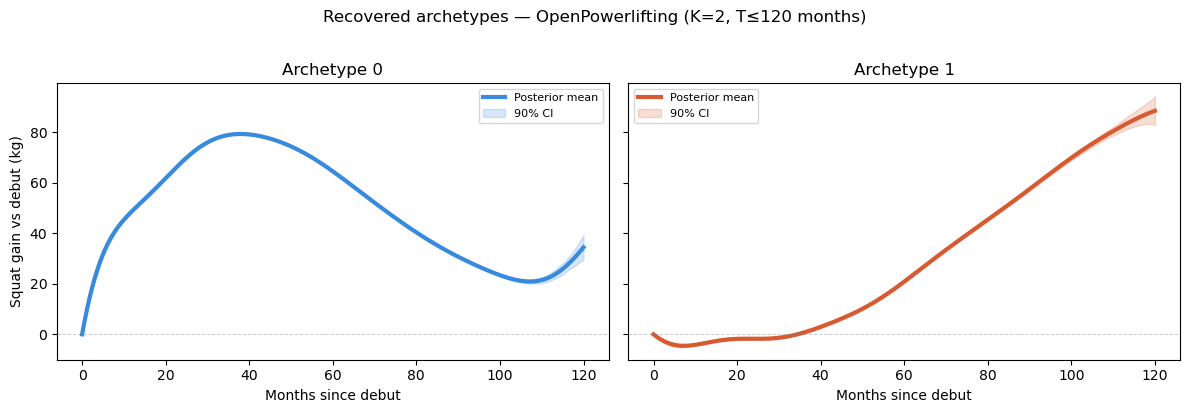

Archetype 0: peak gain = 79.3 kg at month 38
Archetype 1: peak gain = 88.4 kg at month 120


In [9]:
t_grid = np.linspace(0, T_max, 200)

samples, f_grid, full_u_fn = extract_posterior(
    guide, t_t, id_t, N, K, Z, t_grid)

f_mean = f_grid.mean(axis=0)
f_lo   = np.quantile(f_grid, 0.05, axis=0)
f_hi   = np.quantile(f_grid, 0.95, axis=0)

colors = ["#378ADD", "#D85A30", "#1D9E75"]   # blue, orange, green
fig, axes = plt.subplots(1, K, figsize=(6 * K, 4), sharey=True)
for k in range(K):
    axes[k].plot(t_grid, f_mean[k], color=colors[k], lw=3, label="Posterior mean")
    axes[k].fill_between(t_grid, f_lo[k], f_hi[k],
                         color=colors[k], alpha=0.2, label="90% CI")
    axes[k].axhline(0, color="gray", lw=0.7, ls="--", alpha=0.4)
    axes[k].set_title(f"Archetype {k}")
    axes[k].set_xlabel("Months since debut")
    axes[k].legend(fontsize=8)
axes[0].set_ylabel("Squat gain vs debut (kg)")
plt.suptitle(f"Recovered archetypes — OpenPowerlifting (K={K}, T≤120 months)", y=1.02)
plt.tight_layout(); plt.show()

for k in range(K):
    print(f"Archetype {k}: peak gain = {f_mean[k].max():.1f} kg at "
          f"month {t_grid[f_mean[k].argmax()]:.0f}")

## 6. Posterior predictive for individual lifters

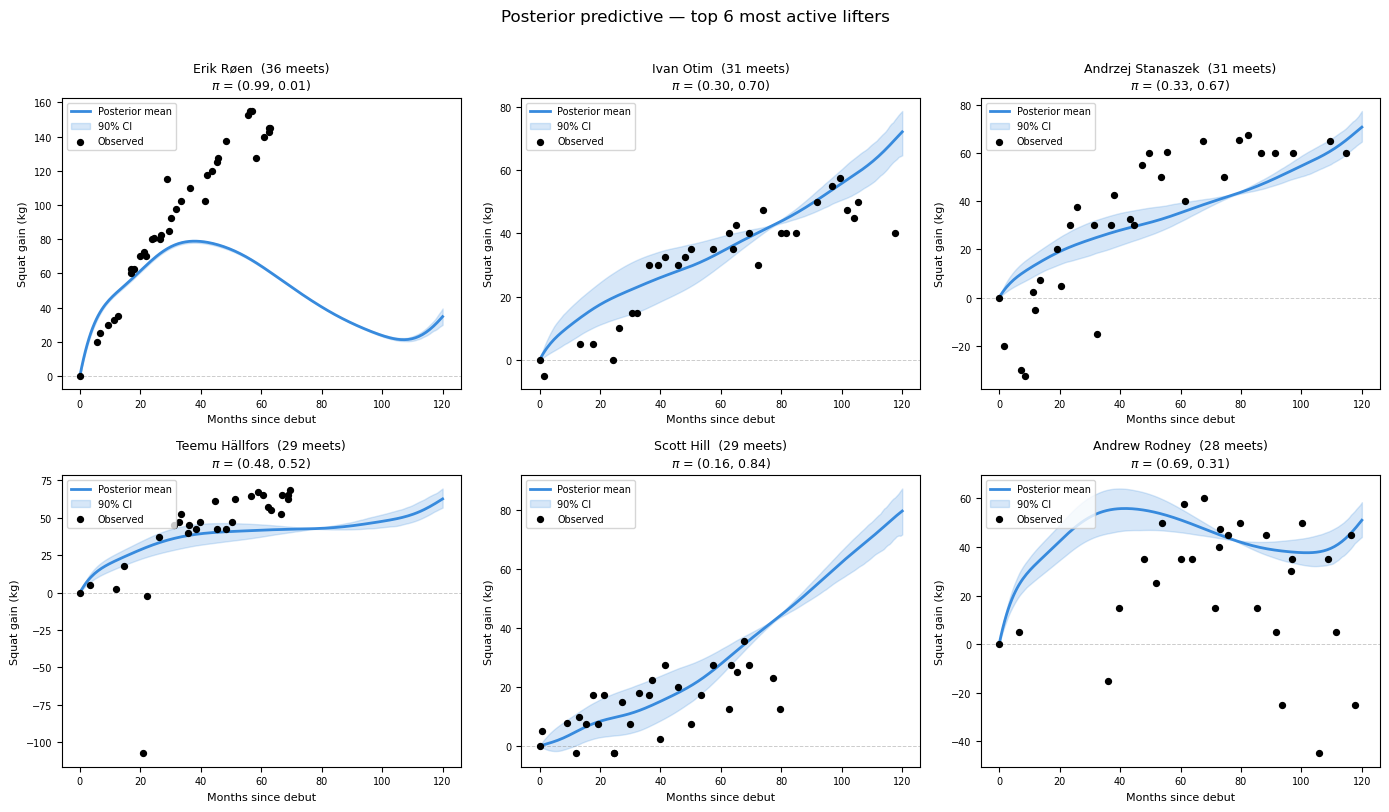

In [17]:
pi_post = samples["pi"].mean(dim=0).numpy()   # (N, K)

def predict_lifter(i, t_query):
    """Posterior predictive for lifter i."""
    t_q  = torch.tensor(t_query)
    n_s  = samples["pi"].shape[0]
    preds = np.zeros((n_s, len(t_query)))
    for s in range(n_s):
        f_vals = np.zeros((K, len(t_query)))
        for k in range(K):
            ls  = samples["lengthscale"][s, k]
            amp = samples["amplitude"][s, k]
            u_k = full_u_fn(k)[s]
            K_ZZ = rbf_kernel(Z, Z, ls, amp)
            K_tZ = rbf_kernel(t_q, Z, ls, amp)
            f_vals[k] = (K_tZ @ torch.linalg.solve(K_ZZ, u_k)).detach().numpy()
        pi_s = samples["pi"][s, i].numpy()
        preds[s] = (pi_s[:, None] * f_vals).sum(axis=0)
    return preds

# Pick 6 lifters with most meets
meet_counts_arr = np.bincount(lifter_id_real)
top6_ids = np.argsort(meet_counts_arr)[::-1][:6]
#top6_ids = np.random.choice(N, size=6, replace=False)
t_query = np.linspace(0, T_max, 200)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, i in zip(axes.flat, top6_ids):
    mask  = lifter_id_real == i
    preds = predict_lifter(i, t_query)
    pred_mean = preds.mean(axis=0)
    pred_lo   = np.quantile(preds, 0.05, axis=0)
    pred_hi   = np.quantile(preds, 0.95, axis=0)

    ax.plot(t_query, pred_mean, color="#378ADD", lw=2, label="Posterior mean")
    ax.fill_between(t_query, pred_lo, pred_hi,
                    color="#378ADD", alpha=0.2, label="90% CI")
    ax.scatter(t_real[mask], y_real[mask], color="black", s=18, zorder=3, label="Observed")
    ax.axhline(0, color="gray", lw=0.7, ls="--", alpha=0.4)

    name    = lifter_names[i]
    pi_str  = ", ".join(f"{p:.2f}" for p in pi_post[i])
    n_meets = mask.sum()
    ax.set_title(f"{name}  ({n_meets} meets)\n$\\pi$ = ({pi_str})", fontsize=9)
    ax.set_xlabel("Months since debut", fontsize=8)
    ax.set_ylabel("Squat gain (kg)", fontsize=8)
    ax.legend(fontsize=7, loc="upper left")
    ax.tick_params(labelsize=7)

plt.suptitle("Posterior predictive — top 6 most active lifters", y=1.01)
plt.tight_layout(); plt.show()

In [11]:
top6_ids

array([ 1399, 10486,  7333,  3234,  4687,  3679])

## 7. Population-level mixing weight analysis

Mean weight per archetype: [0.46108892 0.53891108]
Fraction with pi_0 > 0.7 (predominantly archetype 0): 17.42%
Fraction with pi_1 > 0.7 (predominantly archetype 1): 28.15%
Fraction with neither > 0.7 (blended): 54.42%


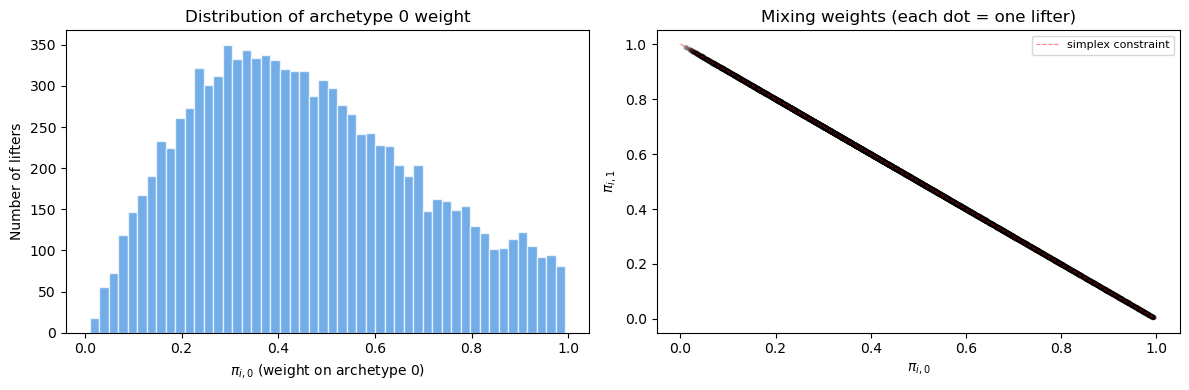

In [12]:
print(f"Mean weight per archetype: {pi_post.mean(axis=0)}")
print(f"Fraction with pi_0 > 0.7 (predominantly archetype 0): {(pi_post[:, 0] > 0.7).mean():.2%}")
print(f"Fraction with pi_1 > 0.7 (predominantly archetype 1): {(pi_post[:, 1] > 0.7).mean():.2%}")
print(f"Fraction with neither > 0.7 (blended): {((pi_post.max(axis=1)) <= 0.7).mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of pi_0
axes[0].hist(pi_post[:, 0], bins=50, color="#378ADD", alpha=0.7, edgecolor="white")
axes[0].set_xlabel("$\\pi_{i,0}$ (weight on archetype 0)")
axes[0].set_ylabel("Number of lifters")
axes[0].set_title("Distribution of archetype 0 weight")

# Scatter: pi_0 vs pi_1 (they sum to 1, so it is a line, but still useful to see density)
axes[1].scatter(pi_post[:, 0], pi_post[:, 1], alpha=0.15, s=8, c="black")
axes[1].set_xlabel("$\\pi_{i,0}$"); axes[1].set_ylabel("$\\pi_{i,1}$")
axes[1].set_title("Mixing weights (each dot = one lifter)")
axes[1].plot([0, 1], [1, 0], 'r--', lw=0.8, alpha=0.5, label="simplex constraint")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 8. Outlier analysis — worst-fit lifters

Rank lifters by mean squared residual to identify those whose trajectories the static-$\pi$ model fits poorly. These are candidates for structural breaks (federation switches, injuries, doping bans).

Top 10 worst-fit lifters (by MSE):
Name                                  MSE  Meets   pi_0   pi_1
Darren Nemow                      22025.9     11   0.92   0.08
Christopher Rousch                21875.3      4   0.97   0.03
Jere Karttunen                    15975.2      8   0.99   0.01
Zach Smith                        14625.0      7   0.98   0.02
Brett Gibbs                       13726.5     18   0.99   0.01
Jezza Uepa                        12614.6     22   0.99   0.01
Tommi Peters                      12150.3      6   0.99   0.01
Justin Davis                      10762.3      9   0.99   0.01
Louis Zabala                      10526.9      7   0.99   0.01
James Strickland                   9888.5      8   0.99   0.01


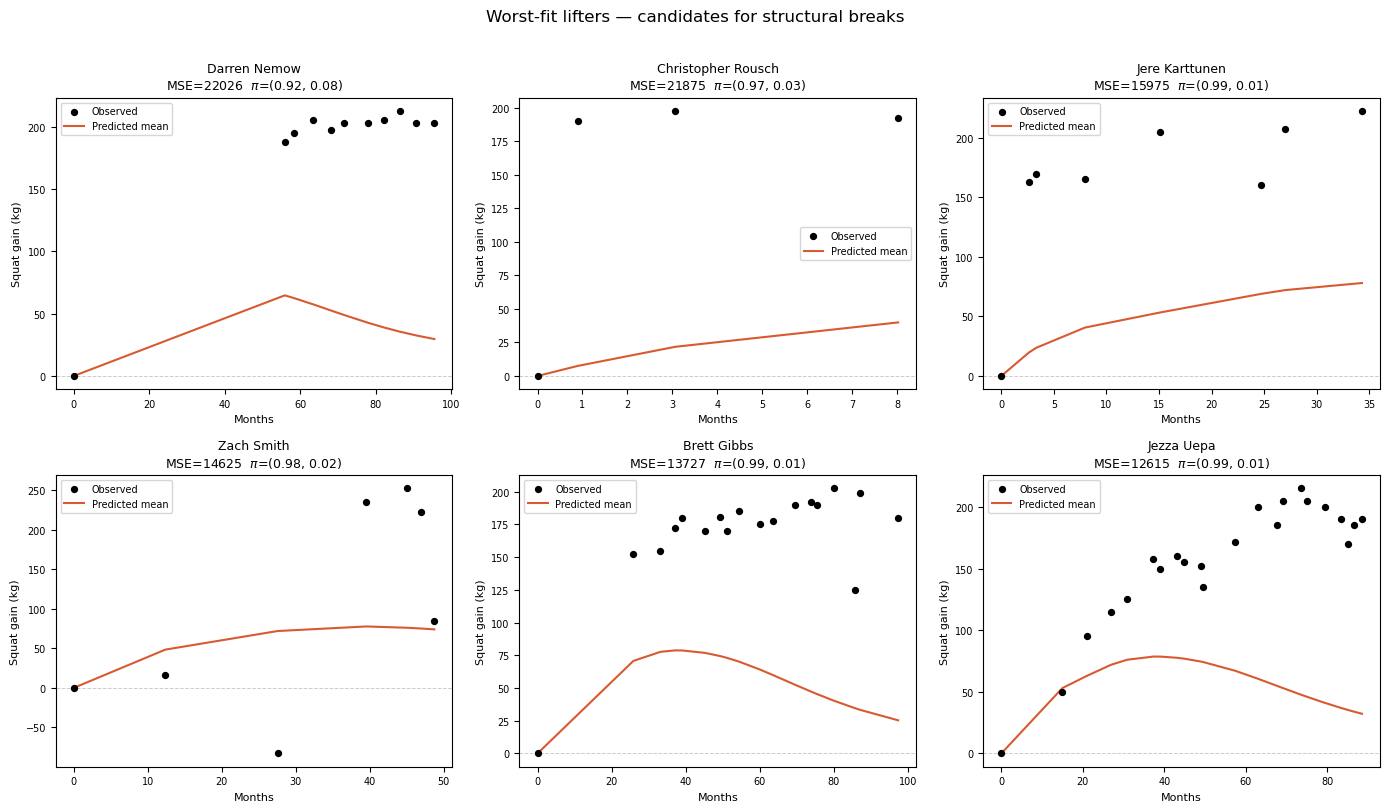

In [13]:
# Compute posterior predictive mean for every observation
pred_all = predict_lifter.__wrapped__ if hasattr(predict_lifter, '__wrapped__') else None

# Simpler: compute mean prediction at each observed time point directly
f_mean_at_Z = {}
ls_mean = samples["lengthscale"].mean(dim=0)
amp_mean = samples["amplitude"].mean(dim=0)
u_mean = {}
for k in range(K):
    u_free_mean = samples[f"u_{k}"].mean(dim=0)
    u_mean[k] = torch.cat([torch.zeros(1, dtype=u_free_mean.dtype), u_free_mean])

f_at_all = torch.zeros(K, len(t_real))
for k in range(K):
    K_ZZ = rbf_kernel(Z, Z, ls_mean[k], amp_mean[k])
    K_tZ = rbf_kernel(t_t, Z, ls_mean[k], amp_mean[k])
    f_at_all[k] = K_tZ @ torch.linalg.solve(K_ZZ, u_mean[k])

pi_mean_t = torch.tensor(pi_post, dtype=torch.float64)
pi_per_obs = pi_mean_t[id_t]
y_pred = (pi_per_obs * f_at_all.T).sum(dim=-1).detach().numpy()
residuals = y_real - y_pred

# Mean squared error per lifter
mse_per_lifter = np.zeros(N)
for i in range(N):
    mask = lifter_id_real == i
    mse_per_lifter[i] = (residuals[mask] ** 2).mean()

# Top 10 worst-fit lifters
worst10 = np.argsort(mse_per_lifter)[::-1][:10]
print("Top 10 worst-fit lifters (by MSE):")
print(f"{'Name':<30s} {'MSE':>10s} {'Meets':>6s} {'pi_0':>6s} {'pi_1':>6s}")
for i in worst10:
    mask = lifter_id_real == i
    print(f"{lifter_names[i]:<30s} {mse_per_lifter[i]:10.1f} {mask.sum():6d} "
          f"{pi_post[i, 0]:6.2f} {pi_post[i, 1]:6.2f}")

# Plot worst 6
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, i in zip(axes.flat, worst10[:6]):
    mask = lifter_id_real == i
    ax.scatter(t_real[mask], y_real[mask], color="black", s=18, zorder=3, label="Observed")
    ax.plot(t_real[mask], y_pred[mask], color="#D85A30", lw=1.5, label="Predicted mean")
    ax.axhline(0, color="gray", lw=0.7, ls="--", alpha=0.4)
    name = lifter_names[i]
    pi_str = ", ".join(f"{p:.2f}" for p in pi_post[i])
    ax.set_title(f"{name}\nMSE={mse_per_lifter[i]:.0f}  $\\pi$=({pi_str})", fontsize=9)
    ax.set_xlabel("Months", fontsize=8)
    ax.set_ylabel("Squat gain (kg)", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
plt.suptitle("Worst-fit lifters — candidates for structural breaks", y=1.01)
plt.tight_layout(); plt.show()

## Next steps

- **Try K=3 on the capped data** now that the time domain is restricted. The cap may resolve the collapse.
- **MCMC comparison**: run NUTS on a subset of ~30 lifters and compare posterior to the SVI approximation.
- **Model comparison**: fit a single pooled GP (K=1, no mixture) and an independent GP per lifter as baselines. Compare held-out predictive log-likelihood.
- **Outlier investigation**: look up the worst-fit lifters from section 8 in public records — federation switches, equipment changes, documented bans.
- **Covariates**: add bodyweight as a linear shift on the mean to separate level effects from trajectory shape.